<a href="https://colab.research.google.com/github/devdyuthi/poweredbyplastic_isef26/blob/main/plastic_contamination_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
''' SETUP -- THE FOLLOWING CODE MAKES SURE THAT COLAB IS
 1) ABLE TO ACCESS THE drive ( IMAGES & CSV)
 2) IS ABLE TO PERFORM OPERATIONS USING IMAGES AND csv
 3) SPLITS ENTIRE DATASET INTO TRAINING/TESTING ( 85% is used for training, 15% for testing)
 4) PRINTS SMTH CALLED A "SHAPE" ( this is more for me than you tbh ) , it's in the format
     - (number_of_images, height, width, channels)
     - channels are color channels so should be RGB -> 3 channels

devna - 12/2/25'''

from google.colab import drive
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
from collections import Counter

drive.mount('/content/drive')
labels = pd.read_csv("/content/drive/MyDrive/plastic_contamination_dataset/img_vs_score.csv")
images = "/content/drive/MyDrive/plastic_contamination_dataset/images/"


x = []
y = []

for index, row in labels.iterrows():
    filename = row["filename"]
    img_path = images + filename
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    x.append(img)
    y.append(row["score"])

x = np.array(x)
y = np.array(y)

# defines bin intervals
bins = np.linspace(0, 1, 11)  # 10 bins: 0-0.1,0.1-0.2,...,0.9-1
y_binned = np.digitize(y, bins) - 1
num_classes = len(np.unique(y_binned))

# created weighting to improve the diversity of the dataset and accuracy of model
class_counts = Counter(y_binned)
total_samples = len(y_binned)
class_weight = {cls: total_samples / (num_classes * class_counts[cls]) for cls in class_counts}
print("Class counts:", class_counts)
print("Class weights:", class_weight)

# oversampling of rarer values to ensure realism in the dataset
x_balanced = []
y_balanced = []
y_continuous_balanced = []

min_samples_per_bin = max(50, int(total_samples / num_classes))  # at least 50 per bin
for cls in range(num_classes):
    idxs = np.where(y_binned == cls)[0]
    x_cls = x[idxs]
    y_cls = y_binned[idxs]
    y_cls_cont = y[idxs]

    if len(x_cls) < min_samples_per_bin:
        x_resampled, y_resampled, y_res_resampled = resample(
            x_cls, y_cls, y_cls_cont, replace=True, n_samples=min_samples_per_bin, random_state=42
        )
    else:
        x_resampled, y_resampled, y_res_resampled = x_cls, y_cls, y_cls_cont

    x_balanced.append(x_resampled)
    y_balanced.append(y_resampled)
    y_continuous_balanced.append(y_res_resampled)

x_balanced = np.concatenate(x_balanced)
y_balanced = np.concatenate(y_balanced)
y_continuous_balanced = np.concatenate(y_continuous_balanced)

# train/testing split of data
x_train, x_test, y_train, y_test, y_train_cont, y_test_cont = train_test_split(
    x_balanced, y_balanced, y_continuous_balanced, test_size=0.15, random_state=42
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class counts: Counter({np.int64(0): 51, np.int64(1): 39, np.int64(3): 31, np.int64(4): 26, np.int64(2): 23, np.int64(5): 9, np.int64(6): 6, np.int64(8): 6, np.int64(9): 4, np.int64(7): 4})
Class weights: {np.int64(3): 0.6419354838709678, np.int64(0): 0.39019607843137255, np.int64(1): 0.5102564102564102, np.int64(4): 0.7653846153846153, np.int64(6): 3.316666666666667, np.int64(5): 2.2111111111111112, np.int64(8): 3.316666666666667, np.int64(2): 0.8652173913043478, np.int64(9): 4.975, np.int64(7): 4.975}
Training shape: (425, 128, 128, 3)
Testing shape: (76, 128, 128, 3)


In [ ]:
''' CNN

Jahnavi 1/4/26 - Worked on CNN model
- Applied convolution and pooling to extract spatial features from images,
flattens and passes through fully connected layers to learn from visual features and
contamination score
- Final linear output creates a single predidction that estimates contamination

'''


model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128,128,3)), layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation="relu"), layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation="relu"), layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 683ms/step - accuracy: 0.0824 - loss: 4.9409 - val_accuracy: 0.2237 - val_loss: 2.4922
Epoch 2/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 590ms/step - accuracy: 0.1463 - loss: 4.2068 - val_accuracy: 0.3289 - val_loss: 2.0891
Epoch 3/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 590ms/step - accuracy: 0.3091 - loss: 3.1205 - val_accuracy: 0.4211 - val_loss: 1.8161
Epoch 4/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 601ms/step - accuracy: 0.3723 - loss: 2.1937 - val_accuracy: 0.5132 - val_loss: 1.9184
Epoch 5/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 621ms/step - accuracy: 0.4828 - loss: 1.9096 - val_accuracy: 0.6184 - val_loss: 1.5624
Epoch 6/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 589ms/step - accuracy: 0.5802 - loss: 1.3691 - val_accuracy: 0.6579 - val_loss: 1.1431
Epoch 7/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 578ms/step - accuracy: 0.6183 - loss: 1.0973 - val_accuracy: 0.6184 - val_loss: 1.2671
Epoch 8/45
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 654ms/step - accuracy: 0.6698 - loss: 0.7503 - val_accu

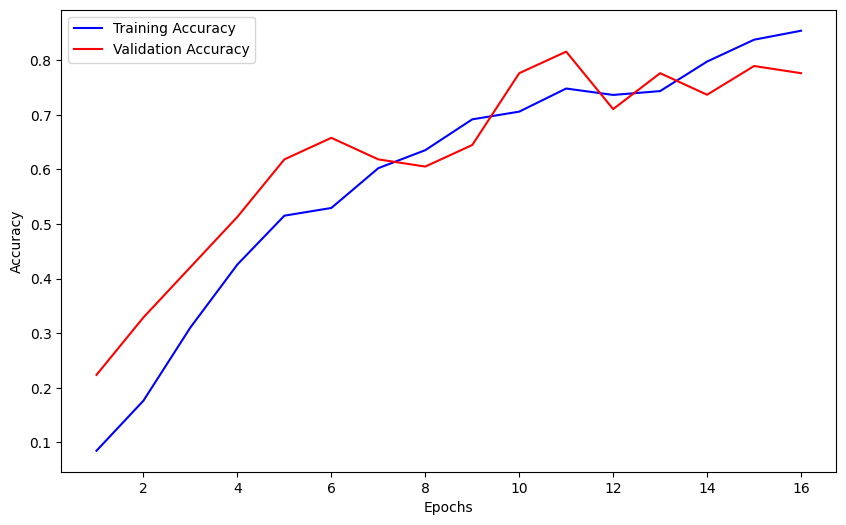

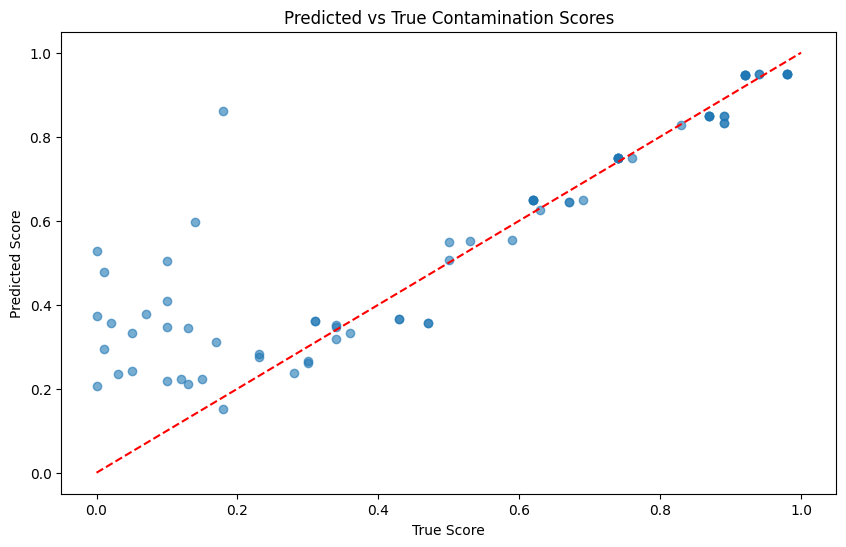

In [ ]:
''' LEARNING METRICS - MEASURES HOW WELL THE MODEL IS FUNCTIONING
* created custom weighting system fit for our purposes
  - penalizes small differences heavily using a weighted versin of Mean Squared Error (MSE) to ensure accuracy
* two graphs
  - Mean Absolute Error (MAE) v. epochs
  - predicted v. truth value
* uses matplotlib to generate graphs to show the learning curve essentially

devna 12/3/25

'''

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# stops model once it isn't learning meaningfully anymore
smart_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# train
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=45,
    batch_size=16,
    callbacks=[smart_stop],
    class_weight=class_weight
)

# prediction
pred_probs = model.predict(x_test)
bin_centers = (bins[:-1] + bins[1:]) / 2  # e.g., 0.05,0.15,...0.95
y_pred_scores = np.sum(pred_probs * bin_centers, axis=1)
y_true_scores = y_test_cont

''' graphical representation '''

# 1: Accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc)+1)
plt.figure(figsize=(10,6))
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 2: Predicted vs True
plt.figure(figsize=(10,6))
plt.scatter(y_true_scores, y_pred_scores, alpha=0.6)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Predicted vs True Contamination Scores")
plt.show()


In [ ]:

#generate data tables

scatter_table = pd.DataFrame({
    "True Score": y_true_scores,
    "Predicted Score": y_pred_scores
})

print("Predicted vs True Scores Table:")
print(scatter_table)

import pandas as pd


acc_table = pd.DataFrame({
    "Epoch": epochs,
    "Training Accuracy": acc,
    "Validation Accuracy": val_acc
})

print("Training/Validation Accuracy Table:")
print(acc_table)

acc_table.to_csv("accuracy_table.csv", index=False)
scatter_table.to_csv("predicted_vs_true.csv", index=False)

from google.colab import files

files.download("predicted_vs_true.csv")
files.download("accuracy_table.csv")


Predicted vs True Scores Table:
    True Score  Predicted Score
0         0.74         0.750000
1         0.10         0.346705
2         0.74         0.750000
3         0.34         0.345839
4         0.30         0.266910
..         ...              ...
71        0.69         0.650042
72        0.53         0.551854
73        0.50         0.506478
74        0.67         0.644609
75        0.63         0.626182

[76 rows x 2 columns]
Training/Validation Accuracy Table:
    Epoch  Training Accuracy  Validation Accuracy
0       1           0.084706             0.223684
1       2           0.176471             0.328947
2       3           0.310588             0.421053
3       4           0.425882             0.513158
4       5           0.515294             0.618421
5       6           0.529412             0.657895
6       7           0.602353             0.618421
7       8           0.635294             0.605263
8       9           0.691765             0.644737
9      10           0.705

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")


Final Training Accuracy: 0.8541
Final Validation Accuracy: 0.7763
Final Training Loss: 0.2624
Final Validation Loss: 0.9578
